<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab_06_Aplicacion_De_Metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 06: Aplicacion de Metricas
## Integrantes:

Delgado Ramos Jorge Luis

Alcibia Miranda Yulitza

# Preprocesamiento Completo del Dataset de Meningitis

En este cuadernillo se aplica todo el flujo de preprocesamiento:
1. Carga y limpieza estructural
2. Separacion 80% entrenamiento y 20% prueba
3. Manejo de valores nulos
4. Codificacion de variables categoricas
5. Normalizacion de caracteristicas
6. Balanceo de clases
7. Conversor a tensores (PyTorch)

In [ ]:
# 1. IMPORTACION DE LIBRERIAS

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from IPython.display import display

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Llamamos al dataset

In [ ]:
ruta_archivo = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 06/mening_missing_12.csv'
df = pd.read_csv(ruta_archivo)

print('Dimensiones originales:', df.shape)
print('Columnas:')
print(df.columns.tolist())
print('Valores nulos por columna:')
print(df.isnull().sum())
display(df.head())

Dimensiones originales: (1200, 14)
Columnas:
['Patient_ID', 'Age', 'Gender', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level', 'Risk_Level']
Valores nulos por columna:
Patient_ID           0
Age                  7
Gender               9
WBC_Count            8
Protein_Level       10
Glucose_Level        8
Pathogen_Present     8
Diagnosis           12
Outcome             10
Hemoglobin          19
WBC_Blood_Count     10
Platelets           12
CRP_Level           13
Risk_Level           0
dtype: int64


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk


##  Limpieza estructural y split 80/20
Se elimina `Patient_ID` por ser identificador y luego se separa entrenamiento (80%) y prueba (20%) con indices aleatorios al estilo cuadernillo.

In [ ]:
import torch

if 'Patient_ID' in df.columns:
    df = df.drop(columns=['Patient_ID'])

target_col = 'Risk_Level'

torch.manual_seed(42)

n_total = df.shape[0]
n_test = int(0.2 * n_total)
n_train = n_total - n_test

indices = torch.randperm(n_total).tolist()
train_indices = indices[:n_train]
test_indices = indices[n_train:]

train_df = df.iloc[train_indices].copy()
test_df = df.iloc[test_indices].copy()

print(f'Train: {len(train_df)}/{n_total} ({len(train_df)/n_total*100:.1f}%)')
print(f'Test : {len(test_df)}/{n_total} ({len(test_df)/n_total*100:.1f}%)')
print('Distribucion en train:')
print(train_df[target_col].value_counts())
print('Distribucion en test:')
print(test_df[target_col].value_counts())

Train: 960/1200 (80.0%)
Test : 240/1200 (20.0%)
Distribucion en train:
Risk_Level
Low Risk         449
High Risk        399
Moderate Risk    112
Name: count, dtype: int64
Distribucion en test:
Risk_Level
Low Risk         109
High Risk        106
Moderate Risk     25
Name: count, dtype: int64


## Separar X e y
Se separan variables predictoras y variable objetivo para train y test.

In [ ]:
feature_cols = [c for c in df.columns if c != target_col]

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()
y_train_raw = train_df[target_col].copy()
y_test_raw = test_df[target_col].copy()

print('Features:', feature_cols)
print(X_train_raw.dtypes)

Features: ['Age', 'Gender', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level']
Age                 float64
Gender               object
WBC_Count           float64
Protein_Level       float64
Glucose_Level       float64
Pathogen_Present     object
Diagnosis            object
Outcome              object
Hemoglobin          float64
WBC_Blood_Count     float64
Platelets           float64
CRP_Level           float64
dtype: object


## Manejo de valores nulos
Como en los cuadernillos: mediana para numericas y moda para categoricas, calculado en train y aplicado en train/test.

In [ ]:
numeric_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('Nulos antes (train):', X_train_raw.isnull().sum().sum())
print('Nulos antes (test) :', X_test_raw.isnull().sum().sum())

for col in numeric_cols:
    med = X_train_raw[col].median()
    X_train_raw[col] = X_train_raw[col].fillna(med)
    X_test_raw[col] = X_test_raw[col].fillna(med)

for col in categorical_cols:
    moda = X_train_raw[col].mode()[0]
    X_train_raw[col] = X_train_raw[col].fillna(moda)
    X_test_raw[col] = X_test_raw[col].fillna(moda)

print('Nulos despues (train):', X_train_raw.isnull().sum().sum())
print('Nulos despues (test) :', X_test_raw.isnull().sum().sum())

Nulos antes (train): 99
Nulos antes (test) : 27
Nulos despues (train): 0
Nulos despues (test) : 0


## Funciones
Se define la funcion `featureNormalize(X)` exactamente en el estilo de los cuadernillos del inge. También se incluye sigmoide como funcion util para clasificacion posterior.

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

## Codificacion de categoricas y normalizacion de numericas
Se codifica y con LabelEncoder, se codifican categoricas de entrada con OneHotEncoder y se normalizan numericas con `featureNormalize` (train) aplicando `mu` y `sigma` a test.

In [ ]:
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_raw)
y_test = target_encoder.transform(y_test_raw)

if categorical_cols:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_cat = ohe.fit_transform(X_train_raw[categorical_cols])
    X_test_cat = ohe.transform(X_test_raw[categorical_cols])
    cat_feature_names = ohe.get_feature_names_out(categorical_cols)
else:
    X_train_cat = np.empty((len(X_train_raw), 0))
    X_test_cat = np.empty((len(X_test_raw), 0))
    cat_feature_names = np.array([])

if numeric_cols:
    X_train_num, mu_norm, sigma_norm = featureNormalize(X_train_raw[numeric_cols].to_numpy())
    X_test_num = (X_test_raw[numeric_cols].to_numpy() - mu_norm) / sigma_norm
else:
    X_train_num = np.empty((len(X_train_raw), 0))
    X_test_num = np.empty((len(X_test_raw), 0))
    mu_norm = np.array([])
    sigma_norm = np.array([])

num_feature_names = np.array(numeric_cols)
final_feature_names = list(num_feature_names) + list(cat_feature_names)

X_train_final = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_final = np.concatenate([X_test_num, X_test_cat], axis=1)

X_train_final_df = pd.DataFrame(X_train_final, columns=final_feature_names, index=X_train_raw.index)
X_test_final_df = pd.DataFrame(X_test_final, columns=final_feature_names, index=X_test_raw.index)

print('X_train final:', X_train_final_df.shape)
print('X_test final :', X_test_final_df.shape)
display(X_train_final_df.head())

X_train final: (960, 17)
X_test final : (240, 17)


,Age,WBC_Count,Protein_Level,Glucose_Level,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Gender_Female,Gender_Male,Pathogen_Present_No,Pathogen_Present_Yes,Diagnosis_Bacterial,Diagnosis_Unknown,Diagnosis_Viral,Outcome_Deceased,Outcome_Recovered
342,-0.075952,-0.443963,-0.896425,0.371395,0.713636,-1.115648,-0.294727,-0.978229,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
184,-0.560699,0.900904,1.100544,-1.183692,0.895357,-0.438397,-0.512186,-0.103339,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
916,2.509363,-1.563384,1.002791,1.983030,0.350193,-1.410819,1.963597,0.581359,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
169,1.297497,-0.674558,1.407770,-1.070595,0.350193,-0.698317,1.805413,-0.902152,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
710,-0.681885,2.268315,1.994293,-0.448560,-1.648744,0.675634,-0.776718,1.988791,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


## Balanceo de clases en entrenamiento
Se realiza undersampling solo en entrenamiento para evitar fuga de informacion hacia prueba.

In [ ]:
train_processed = X_train_final_df.copy()
train_processed[target_col] = y_train
test_processed = X_test_final_df.copy()
test_processed[target_col] = y_test

print('Distribucion antes del balanceo (train):')
print(train_processed[target_col].value_counts().sort_index())

min_count = train_processed[target_col].value_counts().min()
train_balanced = train_processed.groupby(target_col, group_keys=False).sample(n=min_count, random_state=42)

print('Distribucion despues del balanceo (train):')
print(train_balanced[target_col].value_counts().sort_index())
print('Train balanceado:', train_balanced.shape)
print('Test sin balancear:', test_processed.shape)

Distribucion antes del balanceo (train):
Risk_Level
0    399
1    449
2    112
Name: count, dtype: int64
Distribucion despues del balanceo (train):
Risk_Level
0    112
1    112
2    112
Name: count, dtype: int64
Train balanceado: (336, 18)
Test sin balancear: (240, 18)


In [ ]:
print('Train antes del balanceo:')
porc_train = train_processed['Risk_Level'].value_counts(normalize=True).sort_index()
print((round(porc_train * 100, 2)).astype(str) + ' %')

print('\nTrain despues del balanceo:')
porc_bal = train_balanced['Risk_Level'].value_counts(normalize=True).sort_index()
print((round(porc_bal * 100, 2)).astype(str) + ' %')

Train antes del balanceo:
Risk_Level
0    41.56 %
1    46.77 %
2    11.67 %
Name: proportion, dtype: object

Train despues del balanceo:
Risk_Level
0    33.33 %
1    33.33 %
2    33.33 %
Name: proportion, dtype: object


## Conversor a tensores (PyTorch)
En este paso se convierten los conjuntos preprocesados a tensores para usarlos directamente en modelos de PyTorch.

In [ ]:
import torch

X_train_np = train_balanced.drop(columns=[target_col]).to_numpy().astype(np.float32)
y_train_np = train_balanced[target_col].to_numpy().astype(np.int64)
X_test_np = test_processed.drop(columns=[target_col]).to_numpy().astype(np.float32)
y_test_np = test_processed[target_col].to_numpy().astype(np.int64)

X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np)
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np)

print('Preparación terminada:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

Preparación terminada:
X_train shape: torch.Size([336, 17])
y_train shape: torch.Size([336])
X_test shape: torch.Size([240, 17])
y_test shape: torch.Size([240])


# 1. Entrenamiento del Modelo (Red Neuronal MLP)

En esta sección definimos la arquitectura de nuestra **Red Neuronal Multicapa (MLP)**. Para un problema de clasificación de riesgo (como el de Meningitis), la red debe aprender a mapear las variables clínicas (características) hacia una de las categorías de riesgo (etiquetas).

### Componentes clave:
* **Arquitectura:** Una capa de entrada, dos capas ocultas con activación **ReLU** (para introducir no linealidad) y una capa de salida con tantas neuronas como clases tenga nuestro dataset.
* **Función de Pérdida (Loss Function):** Utilizamos **CrossEntropyLoss**, que es el estándar para problemas multiclase, ya que penaliza las predicciones incorrectas comparando las probabilidades logarítmicas del modelo con las etiquetas reales.
* **Optimizador (Adam):** Un algoritmo de descenso de gradiente estocástico adaptativo que ajusta los pesos de la red de manera eficiente.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Configuración de DataLoaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Definición de la Red Neuronal
class RedMeningitis(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedMeningitis, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.red(x)

input_size = X_train.shape[1]
num_classes = len(torch.unique(y_train))
modelo = RedMeningitis(input_size, num_classes)

# 3. Optimización y Pérdida
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# 4. Bucle de Entrenamiento
epochs = 300
historial_loss = []

for epoch in range(epochs):
    modelo.train()
    loss_acumulada = 0.0
    for batch_X, batch_y in train_loader:
        predicciones = modelo(batch_X)
        loss = criterio(predicciones, batch_y)
        optimizador.zero_grad()
        loss.backward()
        optimizador.step()
        loss_acumulada += loss.item()

    historial_loss.append(loss_acumulada / len(train_loader))
    if (epoch + 1) % 50 == 0:
        print(f"Época [{epoch+1}/{epochs}], Loss: {historial_loss[-1]:.4f}")

Época [50/300], Loss: 0.1931
Época [100/300], Loss: 0.0506
Época [150/300], Loss: 0.0139
Época [200/300], Loss: 0.0053
Época [250/300], Loss: 0.0025
Época [300/300], Loss: 0.0014


## 2. Monitoreo: Gráfica de Cross-Entropy (Loss)

La **Curva de Pérdida** es el primer indicador de que el entrenamiento fue exitoso. Representa el "error" del modelo en cada época.

* **Interpretación:** Si la curva desciende suavemente y se estabiliza cerca de cero, significa que el modelo ha convergido y ha dejado de cometer errores masivos.
* **Importancia:** Ayuda a detectar si hubo *Overfitting* (si la pérdida baja demasiado pero el modelo falla en test) o si la tasa de aprendizaje es la adecuada.

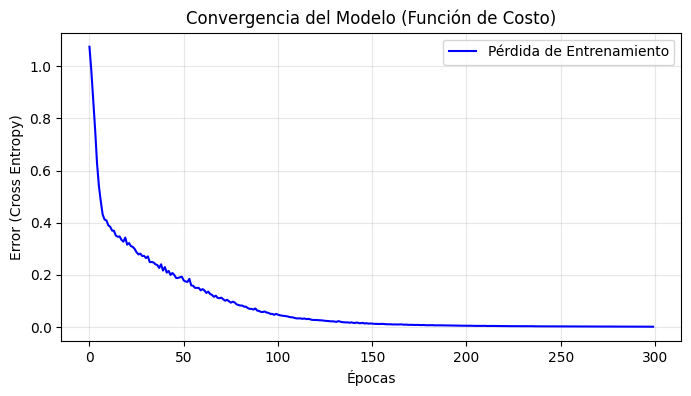

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(historial_loss, color='blue', label='Pérdida de Entrenamiento')
plt.title('Convergencia del Modelo (Función de Costo)')
plt.xlabel('Épocas')
plt.ylabel('Error (Cross Entropy)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Evaluación: Exactitud Global (Accuracy)

La **Exactitud (Accuracy)** es la métrica más intuitiva. Responde a la pregunta: *"De todos los casos presentados, ¿en qué porcentaje acertó el modelo?"*.

Si bien es útil, en problemas médicos se debe tomar con cautela, ya que no distingue entre los tipos de errores (por ejemplo, es más grave no detectar un riesgo alto que dar una falsa alarma en riesgo bajo).

In [ ]:
from sklearn.metrics import accuracy_score

modelo.eval()
with torch.no_grad():
    salidas = modelo(X_test)
    _, predicciones = torch.max(salidas, 1)

y_test_np = y_test.numpy()
predicciones_np = predicciones.numpy()

acc = accuracy_score(y_test_np, predicciones_np)
print(f"La Exactitud Global del modelo es: {acc * 100:.2f}%")

La Exactitud Global del modelo es: 80.00%


## 4. Métricas Detalladas: Precision, Recall y F1-Score

Para entender el desempeño real, desglosamos el éxito del modelo por cada nivel de riesgo utilizando el **Classification Report**:

1.  **Precision (Precisión):** Capacidad del modelo de no dar "falsas alarmas". De todos los pacientes que el modelo etiquetó como "Riesgo Alto", ¿cuántos lo eran realmente?
2.  **Recall (Sensibilidad/Exhaustividad):** Capacidad de detectar todos los casos positivos. De todos los pacientes que **realmente** eran de "Riesgo Alto", ¿cuántos logró encontrar el modelo? **(Métrica vital en medicina)**.
3.  **F1-Score:** Es el promedio armónico entre Precision y Recall. Es útil cuando buscamos un equilibrio entre no dar falsas alarmas y no dejar pasar casos reales.

In [ ]:
from sklearn.metrics import classification_report

print("Reporte de Clasificación Detallado:")
# Mostramos las métricas desglosadas por cada etiqueta de riesgo
print(classification_report(y_test_np, predicciones_np))

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       106
           1       0.91      0.87      0.89       109
           2       0.33      0.64      0.43        25

    accuracy                           0.80       240
   macro avg       0.72      0.76      0.72       240
weighted avg       0.86      0.80      0.82       240



## 5. Análisis Visual: Matriz de Confusión

La **Matriz de Confusión** nos permite observar exactamente dónde se equivoca el modelo. Al ser un problema de 3 clases (Riesgo Bajo, Moderado, Alto), tendremos una cuadrícula de 3x3.

* **Eje Y (Verdadera):** Lo que el paciente realmente tiene (Diagnóstico real).
* **Eje X (Predicción):** Lo que la Inteligencia Artificial diagnosticó.
* **La Diagonal Principal:** Representa los aciertos perfectos. Todo número fuera de esta diagonal es un error del modelo. En medicina, prestamos especial atención a evitar clasificar un "Riesgo Alto" como "Riesgo Bajo".

Generando Matriz de Confusión...


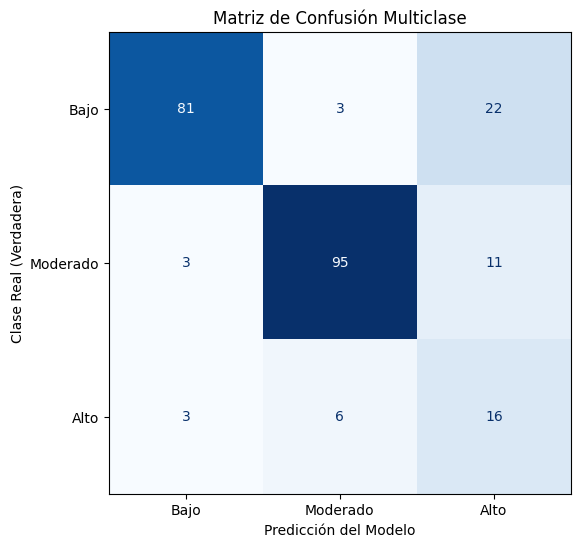

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Generando Matriz de Confusión...")
cm = confusion_matrix(y_test_np, predicciones_np)

# Creamos la visualización de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bajo", "Moderado", "Alto"])

# Graficamos con un mapa de colores azules
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Matriz de Confusión Multiclase')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Verdadera)')
plt.show()

## 6. Rendimiento Robusto: Curva ROC y AUC (One-vs-Rest)

Para no depender de un solo umbral de decisión, utilizamos la **Curva ROC** (Receiver Operating Characteristic) y calculamos el **AUC** (Área Bajo la Curva).

* **Curva ROC:** Grafica la Tasa de Verdaderos Positivos (Recall) contra la Tasa de Falsos Positivos para todos los umbrales de probabilidad posibles.
* **AUC (Area Under the Curve):** Nos da una calificación final. Un AUC de 0.5 significa que el modelo adivina al azar. Un AUC cercano a 1.0 significa que el modelo tiene una capacidad excelente para separar a los pacientes sanos de los graves.
* Al ser multiclase, aplicamos la estrategia **One-vs-Rest** (Una clase contra el resto) para dibujar una línea de rendimiento por cada nivel de riesgo de forma independiente.

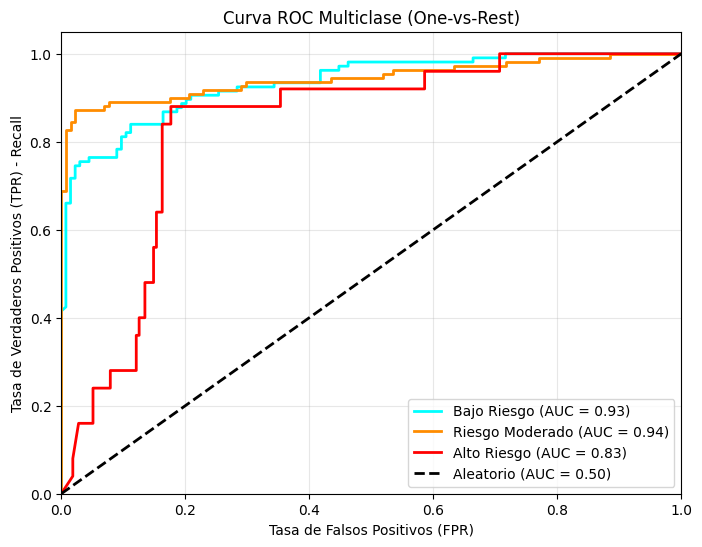

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import torch.nn.functional as F
import numpy as np

# 1. Obtener las probabilidades puras usando Softmax
with torch.no_grad():
    probabilidades = F.softmax(salidas, dim=1).numpy()

# 2. Binarizar las etiquetas (Formato One-vs-Rest)
clases_unicas = np.unique(y_test_np)
y_test_bin = label_binarize(y_test_np, classes=clases_unicas)
n_clases = y_test_bin.shape[1]

# 3. Dibujar la curva ROC para cada clase
plt.figure(figsize=(8, 6))
colores = cycle(['aqua', 'darkorange', 'red']) # Un color por clase
nombres_clases = ["Bajo Riesgo", "Riesgo Moderado", "Alto Riesgo"]

for i, color in zip(range(n_clases), colores):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probabilidades[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{nombres_clases[i]} (AUC = {roc_auc:.2f})')

# Línea del modelo aleatorio (peor escenario)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) - Recall')
plt.title('Curva ROC Multiclase (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 7. Exportación del Modelo a Producción

El paso final de todo proyecto de Machine Learning es **guardar el conocimiento adquirido**. Entrenar una red neuronal requiere tiempo y poder de cómputo; no podemos (ni debemos) entrenarla desde cero cada vez que llegue un paciente nuevo.

Guardaremos los pesos (*weights*) y sesgos (*biases*) ya optimizados en un archivo `.pth`. De esta manera, cualquier otra aplicación o servidor médico podrá cargar este archivo al instante y comenzar a realizar inferencias (predicciones) sobre nuevos pacientes.

In [ ]:
import torch

# Definimos el nombre del archivo de salida
nombre_archivo = 'modelo_meningitis_entrenado.pth'

# Guardamos el diccionario de estado (state_dict) del modelo
torch.save(modelo.state_dict(), nombre_archivo)

print("="*50)
print(f" ¡ÉXITO! Modelo exportado correctamente como '{nombre_archivo}'")
print("El modelo está listo para ser desplegado en producción.")
print("="*50)

 ¡ÉXITO! Modelo exportado correctamente como 'modelo_meningitis_entrenado.pth'
El modelo está listo para ser desplegado en producción.
